# 심부전 예측 데이터셋

## 컬럼정보
1. 나이(Age): 환자의 나이 [세]
1. 성별(Sex): 환자의 성별 [M: 남성, F: 여성]
1. 흉통 유형(ChestPainType): 흉통 유형 [TA: 전형적인 협심증, ATA: 비전형적인 협심증, NAP: 비협심증성 통증, ASY: 무증상]
1. 안정시 혈압(RestingBP): 안정시 혈압 [mmHg]
1. 콜레스테롤(Cholesterol): 혈청 콜레스테롤 [mm/dl]
1. 공복 혈당(FastingBS): 공복 혈당 [1: 공복 혈당 > 120mg/dl, 0: 그렇지 않음]
1. 안정시 심전도(RestingECG): 안정시 심전도 결과 [정상: 정상, ST: ST-T파 이상(T파 역전 및/또는 ST 상승 또는 하강 > 0.05mV), LVH: Estes 기준에 따른 좌심실 비대 가능성 또는 확정]
1. 최대 심박수(MaxHR): 도달한 최대 심박수 [60~202 사이의 숫자 값]
1. 운동성 협심증(ExerciseAngina): 운동 유발성 협심증 [Y: 예, N: 아니오]
1. Oldpeak: oldpeak = ST [하강 정도를 측정한 수치]
1. ST_Slope: 운동 시 최고 ST 분절의 기울기 [Up: 상승, Flat: 평탄, Down: 하강]
1. 심장 질환(HeartDisease): 출력 등급 [1: 심장 질환, 0: 정상]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')


pandas: 2.2.1
numpy: 1.26.4


In [2]:
# 데이터 로딩
df = pd.read_csv('pandas/data/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
# 데이터 기본 정보
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [4]:
# 데이터 기본 통계
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


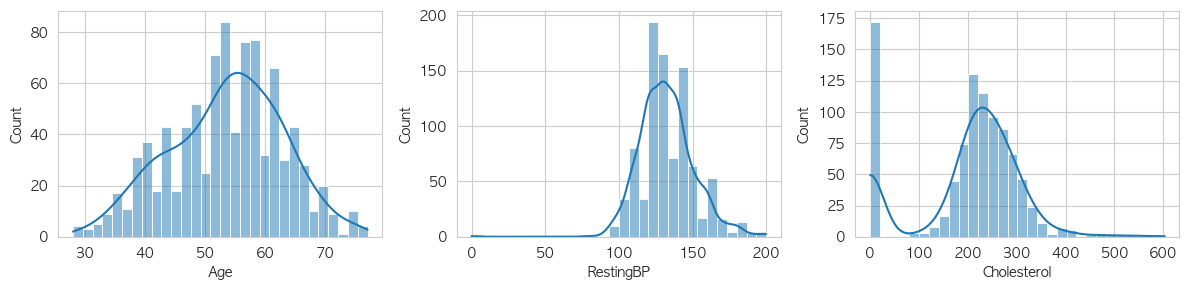

In [5]:
num_cols = ['Age','RestingBP','Cholesterol']
fig, axes = plt.subplots(1,3,figsize=(12,3))
for i, col in enumerate(num_cols):    
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i])

plt.tight_layout()
plt.show() 

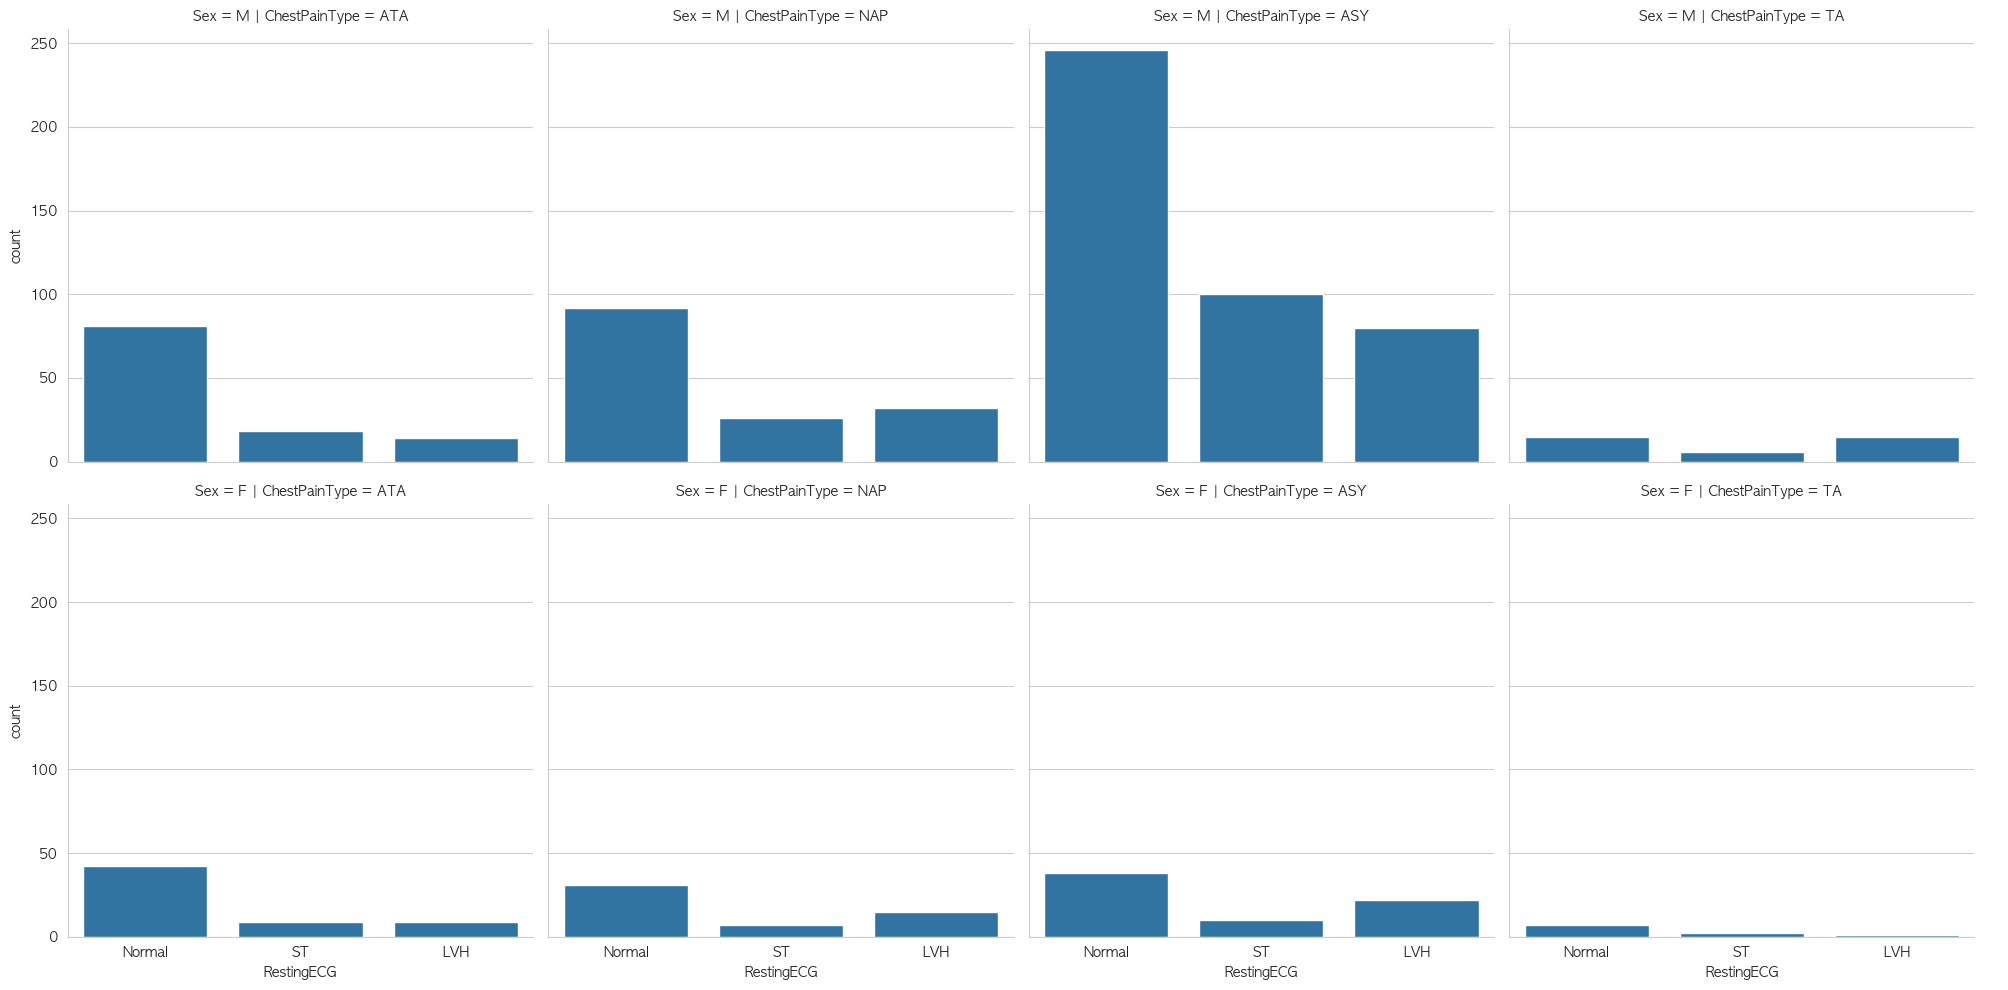

In [6]:
sns.catplot(data=df, x='RestingECG', col='ChestPainType', kind='count', row='Sex')

<Axes: xlabel='count', ylabel='RestingECG'>

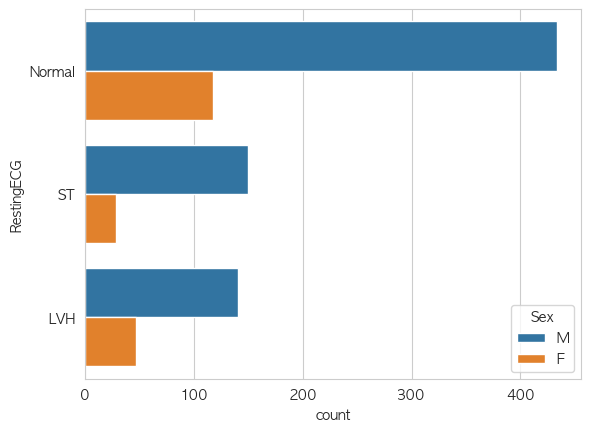

In [7]:
sns.countplot(data=df, y='RestingECG', hue='Sex')

<Axes: xlabel='Cholesterol', ylabel='MaxHR'>

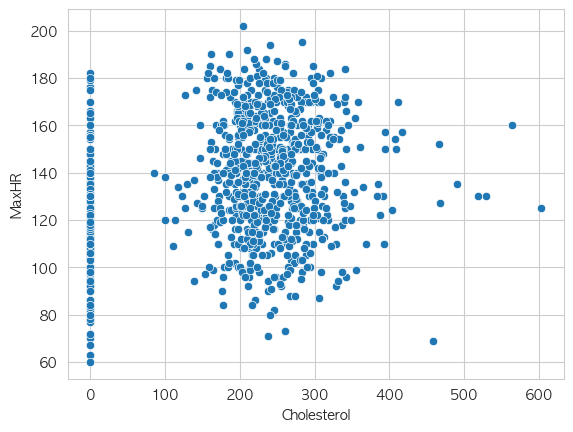

In [8]:
sns.scatterplot(data=df, x='Cholesterol', y='MaxHR')

In [9]:
# 콜레스테롤이 0인 행들의 개수를 파악
df[df['Cholesterol']==0]['Cholesterol'].count()

172

In [10]:
# 범주형 → 수치 변환 (예측 모델에 넣기 위해)
obj_cols = df.select_dtypes("object").columns
df_enc = df.copy()
df_enc = pd.get_dummies(df_enc, drop_first=True, dtype='i1')

df_enc['Cholesterol'] = df_enc['Cholesterol'].replace(0, np.nan)
df_enc.isnull().sum()

Age                    0
RestingBP              0
Cholesterol          172
FastingBS              0
MaxHR                  0
Oldpeak                0
HeartDisease           0
Sex_M                  0
ChestPainType_ATA      0
ChestPainType_NAP      0
ChestPainType_TA       0
RestingECG_Normal      0
RestingECG_ST          0
ExerciseAngina_Y       0
ST_Slope_Flat          0
ST_Slope_Up            0
dtype: int64

In [11]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_enc),
    columns=df_enc.columns
)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    float64
 1   RestingBP          918 non-null    float64
 2   Cholesterol        918 non-null    float64
 3   FastingBS          918 non-null    float64
 4   MaxHR              918 non-null    float64
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    float64
 7   Sex_M              918 non-null    float64
 8   ChestPainType_ATA  918 non-null    float64
 9   ChestPainType_NAP  918 non-null    float64
 10  ChestPainType_TA   918 non-null    float64
 11  RestingECG_Normal  918 non-null    float64
 12  RestingECG_ST      918 non-null    float64
 13  ExerciseAngina_Y   918 non-null    float64
 14  ST_Slope_Flat      918 non-null    float64
 15  ST_Slope_Up        918 non-null    float64
dtypes: float64(16)
memory usag

In [12]:
df_copy = df.copy()
df_copy['Cholesterol'] = df_imputed['Cholesterol'].copy()
df_copy.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,244.902832,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,54.680240,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,212.000000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,239.100000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,273.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [13]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 86.2+ KB


<Axes: xlabel='Cholesterol', ylabel='MaxHR'>

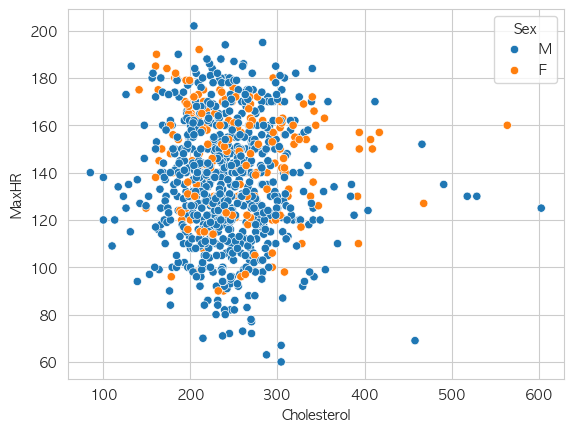

In [14]:
sns.scatterplot(data=df_copy, x='Cholesterol', y='MaxHR', hue='Sex')

<Axes: xlabel='Sex', ylabel='count'>

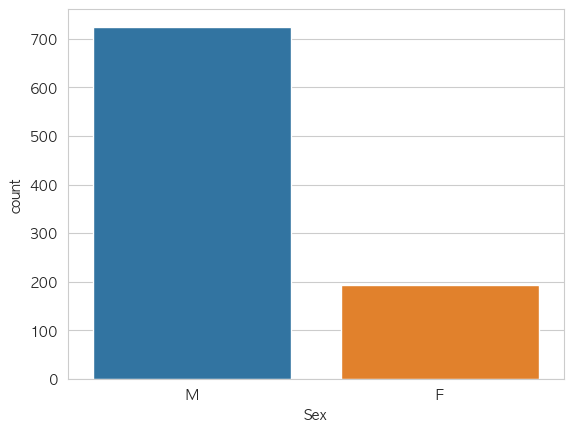

In [15]:
sns.countplot(data=df_copy, x='Sex', hue='Sex')

In [16]:
df_numeric = df_copy.select_dtypes('number')
df_numeric

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
0,40,140,289.0,0,172,0.0,0
1,49,160,180.0,0,156,1.0,1
2,37,130,283.0,0,98,0.0,0
3,48,138,214.0,0,108,1.5,1
4,54,150,195.0,0,122,0.0,0
...,...,...,...,...,...,...,...
913,45,110,264.0,0,132,1.2,1
914,68,144,193.0,1,141,3.4,1
915,57,130,131.0,0,115,1.2,1
916,57,130,236.0,0,174,0.0,1


In [17]:
df_numeric.describe().round(2)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.00,918.00,918.00,918.00,918.00,918.00,918.00
mean,53.51,132.40,244.90,0.23,136.81,0.89,0.55
std,9.43,18.51,54.68,0.42,25.46,1.07,0.50
min,28.00,0.00,85.00,0.00,60.00,-2.60,0.00
25%,47.00,120.00,212.00,0.00,120.00,0.00,0.00
50%,54.00,130.00,239.10,0.00,138.00,0.60,1.00
75%,60.00,140.00,273.00,0.00,156.00,1.50,1.00
max,77.00,200.00,603.00,1.00,202.00,6.20,1.00


In [18]:
df_numeric[df_numeric['RestingBP']==0]['RestingBP'].count()

1

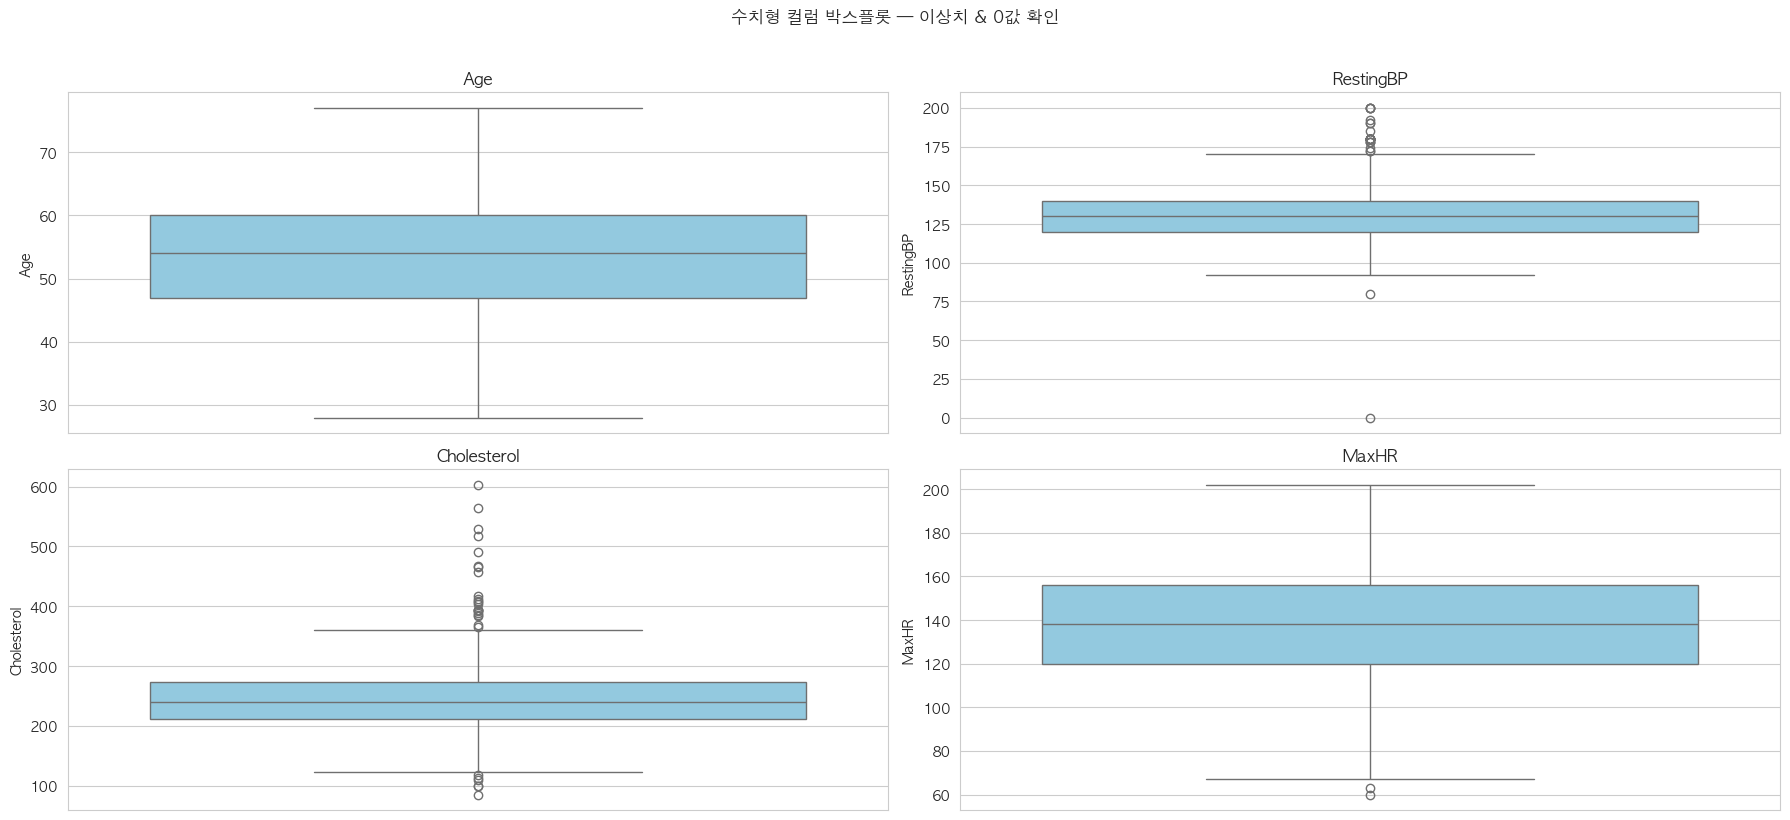

In [19]:
cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']
fig, axes = plt.subplots(2, 2, figsize=(18, 8))
for ax, col in zip(axes.flat, cols):
    sns.boxplot(y=df_copy[col], ax=ax, color='skyblue')
    ax.set_title(col)

for ax in axes.flat[len(cols):]:
    ax.set_visible(False)

plt.suptitle('수치형 컬럼 박스플롯 — 이상치 & 0값 확인', y=1.02)
plt.tight_layout()
plt.show()

In [20]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 86.2+ KB


In [21]:
df_copy['RestingBP'] = df_copy['RestingBP'].replace(0, np.nan)
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       917 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


In [22]:
df_copy = df_copy.dropna()
df_copy.info()


<class 'pandas.core.frame.DataFrame'>
Index: 917 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             917 non-null    int64  
 1   Sex             917 non-null    object 
 2   ChestPainType   917 non-null    object 
 3   RestingBP       917 non-null    float64
 4   Cholesterol     917 non-null    float64
 5   FastingBS       917 non-null    int64  
 6   RestingECG      917 non-null    object 
 7   MaxHR           917 non-null    int64  
 8   ExerciseAngina  917 non-null    object 
 9   Oldpeak         917 non-null    float64
 10  ST_Slope        917 non-null    object 
 11  HeartDisease    917 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 93.1+ KB


In [23]:
df_enc = pd.get_dummies(df_copy, drop_first=True, dtype='i1')

In [24]:
from sklearn.model_selection import train_test_split

X = df_enc.drop(['HeartDisease'], axis=1)
y = df_enc['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')

X_train: (733, 15), X_test: (184, 15)
y_train: (733,), y_test: (184,)


In [25]:
# HeartDisease가 1인 값들의 개수 = 실제 심장병 판정을 받은 사람들의 수
len(np.where(y_test==1)[0])

102

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'X_train_s 평균: {X_train_s.mean():.4f}, 표준편차: {X_train_s.std():.4f}')
print(f'→ 평균≈0, 표준편차≈1이면 스케일링 정상')

X_train_s 평균: -0.0000, 표준편차: 1.0000
→ 평균≈0, 표준편차≈1이면 스케일링 정상


In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
def eval_model(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    result = {}
    result['Accuracy'] = acc
    result['Report'] = report
    result['Confusion'] = cm
    return result

In [29]:
# 평가 출력 함수
def print_eval(name, result:dict):
    print(f'{name}')
    print(f'Accuracy(정확도): {result["Accuracy"]}')
    print()
    print('classification Report')
    print(result['Report'])
    print()
    print('Confusion Matrix')
    df_confusion = pd.DataFrame(result["Confusion"], index=['정상(0)', '심장병(1)'], columns=['정상(0)', '심장병(1)'])
    print(f'{df_confusion}')
    sns.heatmap(df_confusion, annot=True, fmt='1.1f', cmap='Blues')
    
    

Decision Tree(의사결정 나무)
Accuracy(정확도): 0.7554347826086957

classification Report
              precision    recall  f1-score   support

           0       0.73      0.72      0.72        82
           1       0.78      0.78      0.78       102

    accuracy                           0.76       184
   macro avg       0.75      0.75      0.75       184
weighted avg       0.76      0.76      0.76       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      59      23
심장병(1)     22      80


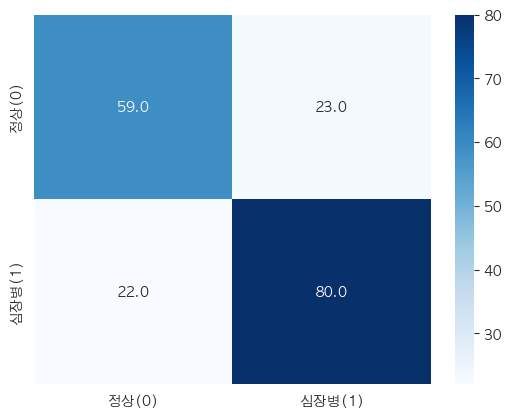

In [30]:
# Decision Tree 생성 및 학습
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

# 예측
y_pred = dtc.predict(X_test)

# 평가
result_dtc = eval_model(y_test, y_pred)
print_eval('Decision Tree(의사결정 나무)', result_dtc)



RandomForest(랜덤포레스트)
Accuracy(정확도): 0.8641304347826086

classification Report
              precision    recall  f1-score   support

           0       0.85      0.84      0.85        82
           1       0.87      0.88      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      69      13
심장병(1)     12      90


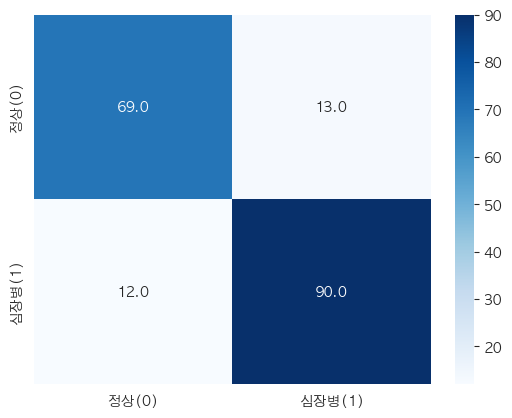

In [31]:
# RandomForest를 이용한 학습 및 예측
rfc = RandomForestClassifier(n_estimators=300, random_state=42)
rfc.fit(X_train, y_train)

# 예측
y_pred = rfc.predict(X_test)

# 평가
result_rfc = eval_model(y_test, y_pred)
print_eval('RandomForest(랜덤포레스트)', result_rfc)

Gradient Boosting(그라디언트 부스팅)
Accuracy(정확도): 0.8695652173913043

classification Report
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        82
           1       0.90      0.86      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      72      10
심장병(1)     14      88


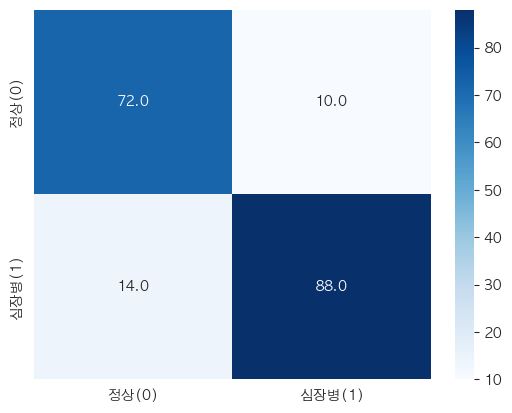

In [32]:
# GradientBoosting 학습 및 평가
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)

# 예측
y_pred = gbc.predict(X_test)

result_gbc = eval_model(y_test, y_pred)
print_eval('Gradient Boosting(그라디언트 부스팅)', result_gbc)

Logistic Regression(로지스틱 회귀)
Accuracy(정확도): 0.875

classification Report
              precision    recall  f1-score   support

           0       0.86      0.85      0.86        82
           1       0.88      0.89      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      70      12
심장병(1)     11      91


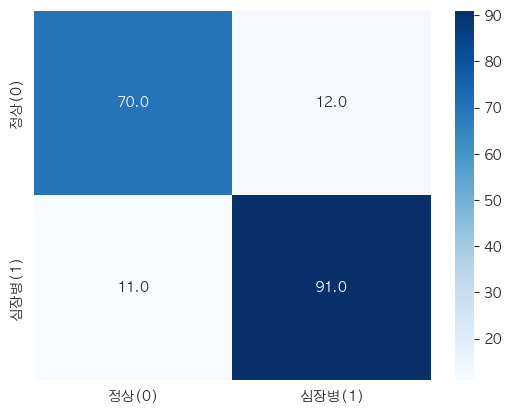

In [33]:
# 로지스틱 회귀
# 로지스틱 회귀는 스케일링이 필요함
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

lg = LogisticRegression(random_state=42)
lg.fit(X_train_s, y_train)

# 예측
y_pred = lg.predict(X_test_s)
result_lg = eval_model(y_test, y_pred)
print_eval('Logistic Regression(로지스틱 회귀)', result_lg)

In [34]:
di = {
    'name':['로지스틱회귀', '디시전트리', '랜덤포레스트', '그라디언트부스팅'],
    'Accuracy':[result_lg['Accuracy'], result_dtc['Accuracy'], result_rfc['Accuracy'], result_gbc['Accuracy']]    
}

df_result = pd.DataFrame(di)
df_result

,name,Accuracy
0,로지스틱회귀,0.875000
1,디시전트리,0.755435
2,랜덤포레스트,0.864130
3,그라디언트부스팅,0.869565


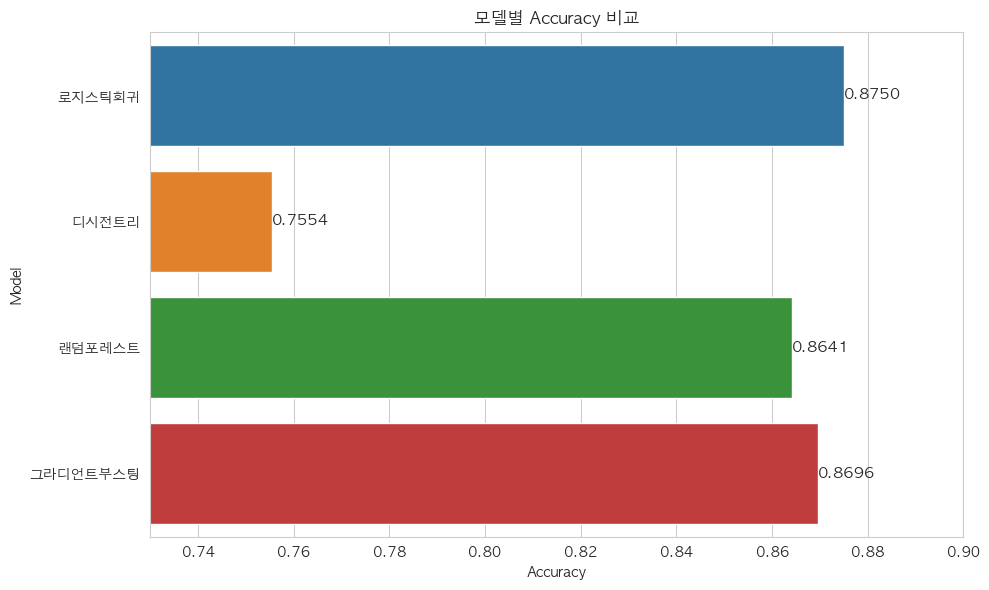

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(df_result, y='name', x='Accuracy', hue='name')
ax.set_xlim(0.73, 0.9)
ax.set_title('모델별 Accuracy 비교')
ax.set_ylabel('Model')
ax.set_xlabel('Accuracy')

# 값 표시 (가로 막대이므로 width가 Accuracy 값)
for p in ax.patches:
  ax.annotate(f'{p.get_width():.4f}',
              (p.get_width(), p.get_y() + p.get_height() / 2),
              ha='left', va='center', fontsize=11)

plt.tight_layout()
plt.show()



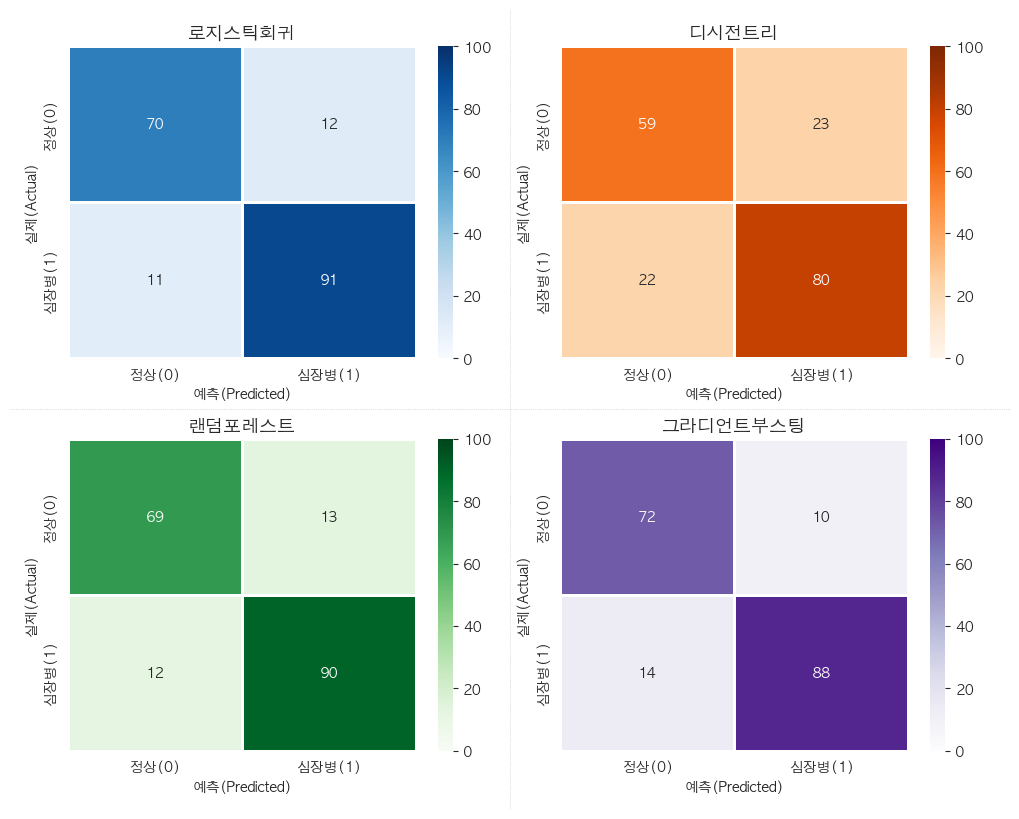

In [36]:
cmaps = ['Blues', 'Oranges', 'Greens', 'Purples']
titles = ['로지스틱회귀', '디시전트리', '랜덤포레스트', '그라디언트부스팅']
results_list = [result_lg, result_dtc, result_rfc, result_gbc]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, result, cmap, title in zip(axes.flat, results_list, cmaps, titles):
  sns.heatmap(result['Confusion'], annot=True, fmt='.0f', cmap=cmap, ax=ax,
              vmin=0, vmax=100, linewidths=2, linecolor='white',
              xticklabels=['정상(0)', '심장병(1)'],
              yticklabels=['정상(0)', '심장병(1)'])
  ax.set_title(title, fontsize=13, fontweight='bold')
  ax.set_xlabel('예측(Predicted)')
  ax.set_ylabel('실제(Actual)')

# 4등분 구분선 (빨간 점선)
fig.add_artist(plt.Line2D([0.5, 0.5], [0, 1], color='grey',
               linestyle=':', linewidth=0.5, alpha=0.5, transform=fig.transFigure))
fig.add_artist(plt.Line2D([0, 1], [0.5, 0.5], color='grey',
               linestyle=':', linewidth=0.5, alpha=0.5, transform=fig.transFigure))

plt.tight_layout()
plt.show()

## 하이퍼튜닝을 이용하여 성능개선

최적 파라미터: {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
최적 CV 점수: 0.8403
Decision Tree (튜닝)
Accuracy(정확도): 0.8043478260869565

classification Report
              precision    recall  f1-score   support

           0       0.76      0.82      0.79        82
           1       0.84      0.79      0.82       102

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.80       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      67      15
심장병(1)     21      81


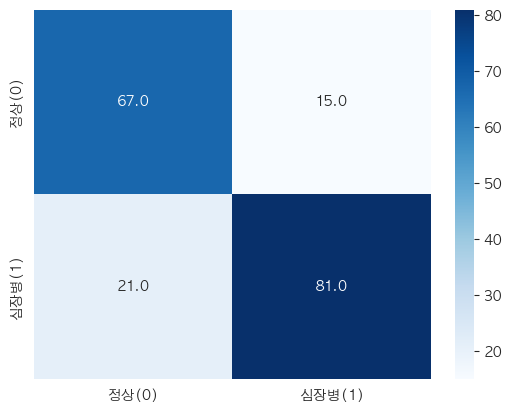

In [37]:
# De
from sklearn.model_selection import GridSearchCV

param_grid = {
  'max_depth': [3, 5, 7, 10],
  'min_samples_split': [2, 5, 10, 20],
  'min_samples_leaf': [1, 5, 10],
}

grid = GridSearchCV(
  DecisionTreeClassifier(random_state=42),
  param_grid,
  cv=5,
  scoring='accuracy',
  n_jobs=-1
)
grid.fit(X_train, y_train)

print(f'최적 파라미터: {grid.best_params_}')
print(f'최적 CV 점수: {grid.best_score_:.4f}')

# 최적 모델로 평가
y_pred = grid.best_estimator_.predict(X_test)
result_dtc_tuned = eval_model(y_test, y_pred)
print_eval('Decision Tree (튜닝)', result_dtc_tuned)

최적 파라미터: {'C': 0.1, 'solver': 'lbfgs'}
최적 CV 점수: 0.8567
Logistic Regression (튜닝)
Accuracy(정확도): 0.8858695652173914

classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.87        82
           1       0.89      0.90      0.90       102

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      71      11
심장병(1)     10      92


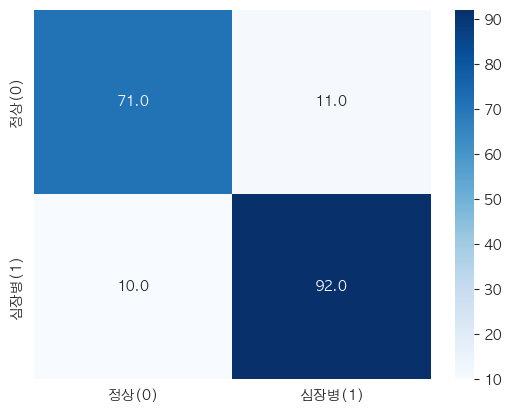

In [38]:
param_grid_lg = {
  'C': [0.01, 0.1, 1, 10, 100],
  'solver': ['lbfgs', 'liblinear'],
}

grid_lg = GridSearchCV(
  LogisticRegression(max_iter=1000, random_state=42),
  param_grid_lg, cv=5, scoring='accuracy', n_jobs=-1
)
grid_lg.fit(X_train_s, y_train)

print(f'최적 파라미터: {grid_lg.best_params_}')
print(f'최적 CV 점수: {grid_lg.best_score_:.4f}')

y_pred = grid_lg.best_estimator_.predict(X_test_s)
result_lg_tuned = eval_model(y_test, y_pred)
print_eval('Logistic Regression (튜닝)', result_lg_tuned)

최적 파라미터: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}
최적 CV 점수: 0.8608
RandomForest (튜닝)
Accuracy(정확도): 0.8641304347826086

classification Report
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      68      14
심장병(1)     11      91


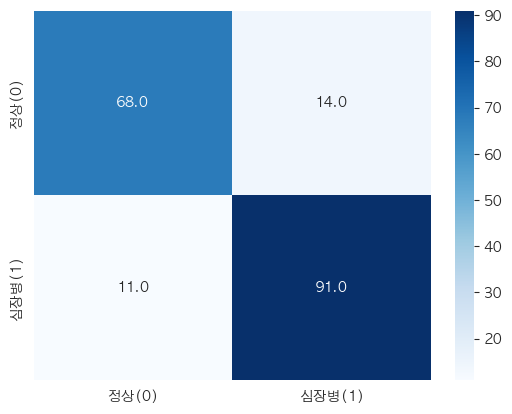

In [39]:
param_grid_rf = {
  'n_estimators': [100, 200, 300],
  'max_depth': [5, 10, 15, None],
  'min_samples_leaf': [1, 3, 5],
}

grid_rf = GridSearchCV(
  RandomForestClassifier(random_state=42),
  param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f'최적 파라미터: {grid_rf.best_params_}')
print(f'최적 CV 점수: {grid_rf.best_score_:.4f}')

y_pred = grid_rf.best_estimator_.predict(X_test)
result_rfc_tuned = eval_model(y_test, y_pred)
print_eval('RandomForest (튜닝)', result_rfc_tuned)


최적 파라미터: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
최적 CV 점수: 0.8662
GradientBoosting (튜닝)
Accuracy(정확도): 0.8804347826086957

classification Report
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      70      12
심장병(1)     10      92


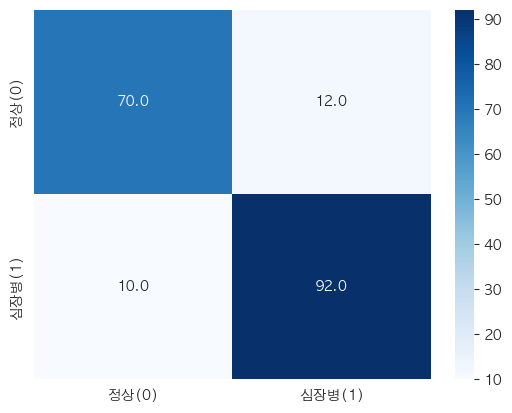

In [40]:
param_grid_gb = {
  'n_estimators': [100, 200, 300],
  'max_depth': [3, 5, 7],
  'learning_rate': [0.01, 0.05, 0.1, 0.2],
}

grid_gb = GridSearchCV(
  GradientBoostingClassifier(random_state=42),
  param_grid_gb, cv=5, scoring='accuracy', n_jobs=-1
)
grid_gb.fit(X_train, y_train)

print(f'최적 파라미터: {grid_gb.best_params_}')
print(f'최적 CV 점수: {grid_gb.best_score_:.4f}')

y_pred = grid_gb.best_estimator_.predict(X_test)
result_gbc_tuned = eval_model(y_test, y_pred)
print_eval('GradientBoosting (튜닝)', result_gbc_tuned)


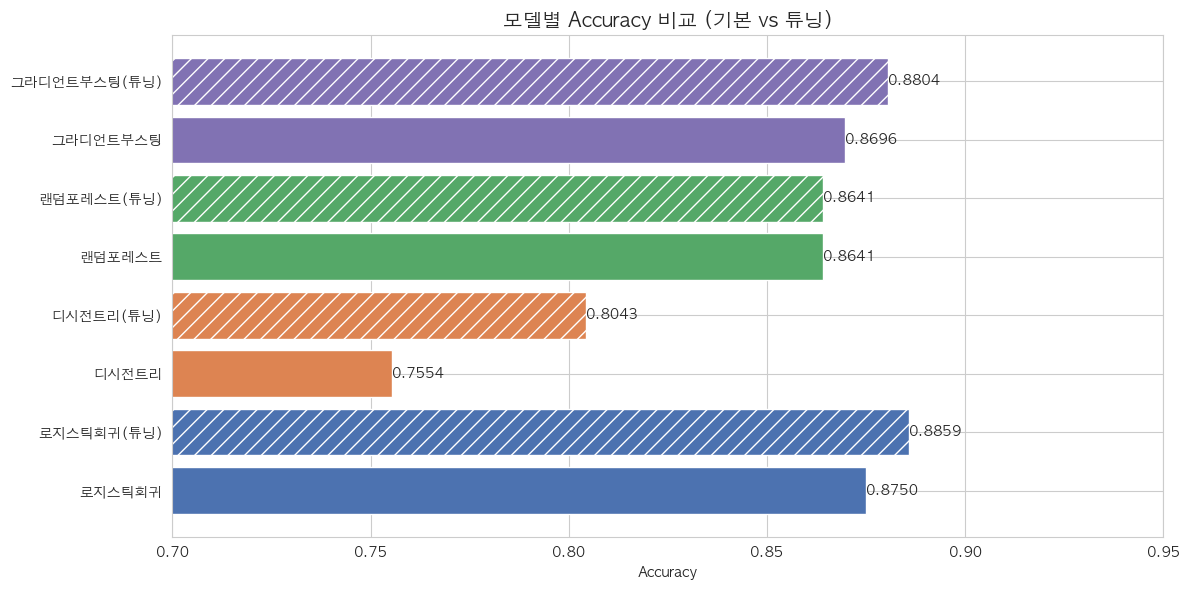

In [41]:
di_all = {
  'name': [
    '로지스틱회귀', '로지스틱회귀(튜닝)',
    '디시전트리', '디시전트리(튜닝)',
    '랜덤포레스트', '랜덤포레스트(튜닝)',
    '그라디언트부스팅', '그라디언트부스팅(튜닝)',
  ],
  'Accuracy': [
    result_lg['Accuracy'], result_lg_tuned['Accuracy'],
    result_dtc['Accuracy'], result_dtc_tuned['Accuracy'],
    result_rfc['Accuracy'], result_rfc_tuned['Accuracy'],
    result_gbc['Accuracy'], result_gbc_tuned['Accuracy'],
  ]
}

df_all = pd.DataFrame(di_all)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452',
          '#55A868', '#55A868', '#8172B3', '#8172B3']
hatches = ['', '//'] * 4  # 튜닝 모델은 빗금

bars = ax.barh(df_all['name'], df_all['Accuracy'], color=colors, edgecolor='white')
for bar, h in zip(bars, hatches):
  bar.set_hatch(h)

ax.set_xlim(0.7, 0.95)
ax.set_title('모델별 Accuracy 비교 (기본 vs 튜닝)', fontsize=14)
ax.set_xlabel('Accuracy')

for p in ax.patches:
  ax.annotate(f'{p.get_width():.4f}',
              (p.get_width(), p.get_y() + p.get_height() / 2),
              ha='left', va='center', fontsize=10)

plt.tight_layout()
plt.show()


## Deep Learning

In [42]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping


tf.random.set_seed(42)

In [43]:
model = Sequential(name='DL')
model.add(layers.Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

callback = [
    EarlyStopping('val_loss', patience=10, verbose=1, restore_best_weights=True)
]

model.compile(
  optimizer=keras.optimizers.Adam(learning_rate=5e-4),
  loss='binary_crossentropy',
  metrics=['accuracy']
)

model.summary()


Model: "DL"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                512       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dense_2 (Dense)             (None, 1)                 17        
                                                                 
Total params: 1057 (4.13 KB)
Trainable params: 1057 (4.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### 학습

In [44]:
history = model.fit(
    X_train_s, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=callback,
    verbose=1
)

Epoch 1/200
37/37 [==============================] - 1s 4ms/step - loss: 0.7695 - accuracy: 0.4761 - val_loss: 0.6581 - val_accuracy: 0.6122
Epoch 2/200
37/37 [==============================] - 0s 1ms/step - loss: 0.6608 - accuracy: 0.6297 - val_loss: 0.5898 - val_accuracy: 0.7483
Epoch 3/200
37/37 [==============================] - 0s 1ms/step - loss: 0.5839 - accuracy: 0.7406 - val_loss: 0.5433 - val_accuracy: 0.7959
Epoch 4/200
37/37 [==============================] - 0s 1ms/step - loss: 0.5299 - accuracy: 0.7696 - val_loss: 0.5067 - val_accuracy: 0.8163
Epoch 5/200
37/37 [==============================] - 0s 1ms/step - loss: 0.4820 - accuracy: 0.7986 - val_loss: 0.4831 - val_accuracy: 0.7959
Epoch 6/200
37/37 [==============================] - 0s 1ms/step - loss: 0.4393 - accuracy: 0.8225 - val_loss: 0.4669 - val_accuracy: 0.7959
Epoch 7/200
37/37 [==============================] - 0s 1ms/step - loss: 0.4164 - accuracy: 0.8379 - val_loss: 0.4580 - val_accuracy: 0.8163
Epoch 8/200
3

In [45]:
# 학습 곡선
def plot_history(history, title='Learning Curve'):
  fig, axes = plt.subplots(1, 2, figsize=(13, 4))
  axes[0].plot(history.history['loss'], label='train')
  axes[0].plot(history.history['val_loss'], label='val')
  axes[0].set_title(f'{title} — Loss')
  axes[0].legend()
  axes[1].plot(history.history['accuracy'], label='train')
  axes[1].plot(history.history['val_accuracy'], label='val')
  axes[1].set_title(f'{title} — Accuracy')
  axes[1].legend()
  plt.tight_layout()
  plt.show()

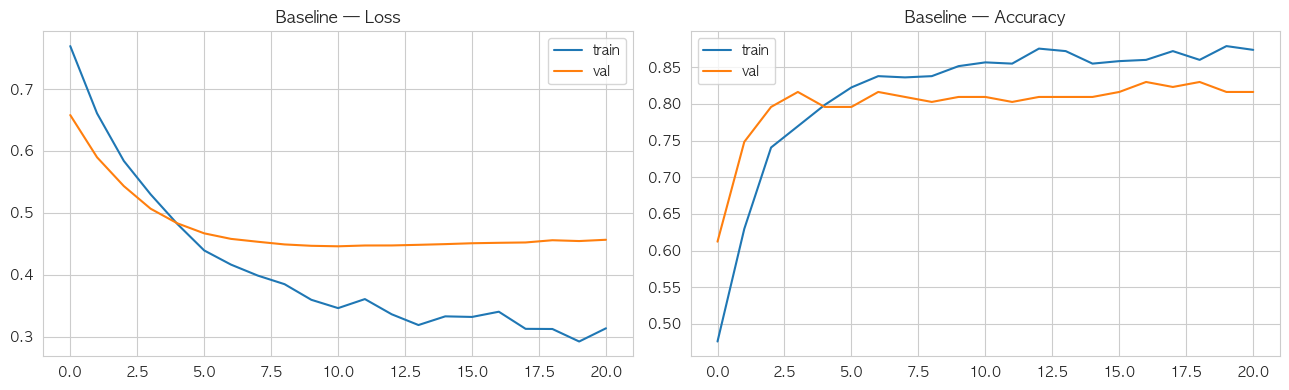

In [46]:
plot_history(history, 'Baseline')

### DL 모델 예측 및 평가

DL (Deep Learning)
Accuracy(정확도): 0.8695652173913043

classification Report
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        82
           1       0.90      0.86      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184


Confusion Matrix
        정상(0)  심장병(1)
정상(0)      72      10
심장병(1)     14      88


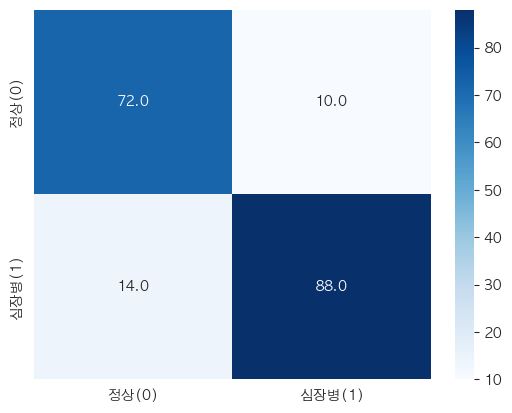

In [47]:
# DL 예측
y_pred_dl = (model.predict(X_test_s, verbose=0) >= 0.5).astype(int).flatten()

# 평가
result_dl = eval_model(y_test, y_pred_dl)
print_eval('DL (Deep Learning)', result_dl)

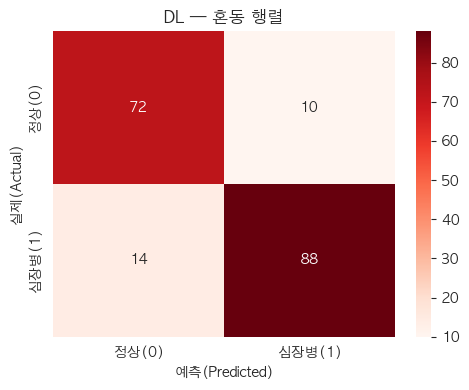

In [48]:
# DL 혼동 행렬
cm_dl = confusion_matrix(y_test, y_pred_dl)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dl, annot=True, fmt='d', cmap='Reds',
            xticklabels=['정상(0)', '심장병(1)'],
            yticklabels=['정상(0)', '심장병(1)'])
plt.xlabel('예측(Predicted)')
plt.ylabel('실제(Actual)')
plt.title('DL — 혼동 행렬')
plt.tight_layout()
plt.show()

### ML vs DL 최종 비교

In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# DL 확률값 (AUC 계산용)
y_prob_dl = model.predict(X_test_s, verbose=0).flatten()

# 전체 모델 결과 취합
all_results = {}

model_info = [
  ('로지스틱회귀', result_lg),
  ('디시전트리', result_dtc),
  ('랜덤포레스트', result_rfc),
  ('그라디언트부스팅', result_gbc),
]

# ML 모델 (eval_model에서 Accuracy, Report, Confusion만 저장했으므로 재계산)
ml_preds = {
  '로지스틱회귀': lg.predict(X_test_s),
  '디시전트리': dtc.predict(X_test),
  '랜덤포레스트': rfc.predict(X_test),
  '그라디언트부스팅': gbc.predict(X_test),
}

ml_probs = {
  '로지스틱회귀': lg.predict_proba(X_test_s)[:, 1],
  '디시전트리': dtc.predict_proba(X_test)[:, 1],
  '랜덤포레스트': rfc.predict_proba(X_test)[:, 1],
  '그라디언트부스팅': gbc.predict_proba(X_test)[:, 1],
}

for name in ml_preds:
  pred = ml_preds[name]
  prob = ml_probs[name]
  all_results[name] = {
    'Accuracy':  accuracy_score(y_test, pred),
    'Precision': precision_score(y_test, pred),
    'Recall':    recall_score(y_test, pred),
    'F1':        f1_score(y_test, pred),
    'AUC':       roc_auc_score(y_test, prob),
  }

# DL 추가
all_results['DL'] = {
  'Accuracy':  accuracy_score(y_test, y_pred_dl),
  'Precision': precision_score(y_test, y_pred_dl),
  'Recall':    recall_score(y_test, y_pred_dl),
  'F1':        f1_score(y_test, y_pred_dl),
  'AUC':       roc_auc_score(y_test, y_prob_dl),
}

df_compare = pd.DataFrame(all_results).T.round(4)
print('=== ML vs DL 전체 비교 ===')
print(df_compare)

=== ML vs DL 전체 비교 ===
          Accuracy  Precision  Recall      F1     AUC
로지스틱회귀      0.8750     0.8835  0.8922  0.8878  0.9378
디시전트리       0.7554     0.7767  0.7843  0.7805  0.7519
랜덤포레스트      0.8641     0.8738  0.8824  0.8780  0.9274
그라디언트부스팅    0.8696     0.8980  0.8627  0.8800  0.9289
DL          0.8696     0.8980  0.8627  0.8800  0.9393


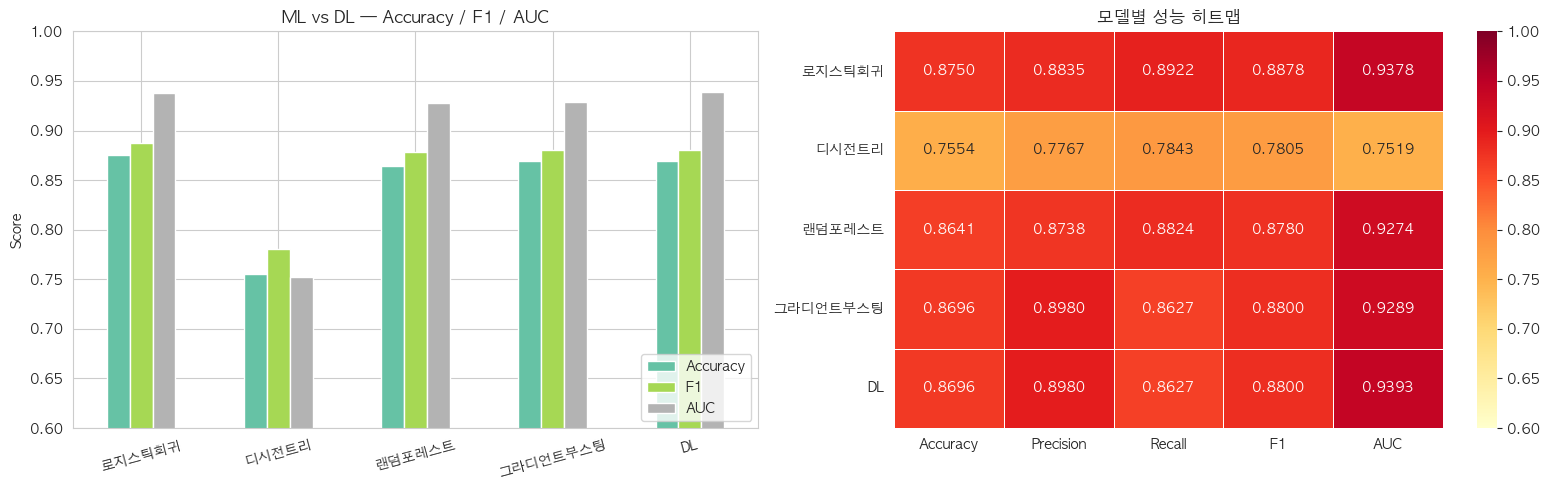

In [50]:
# 막대 그래프
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_compare[['Accuracy', 'F1', 'AUC']].plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('ML vs DL — Accuracy / F1 / AUC')
axes[0].set_ylim(0.6, 1.0)
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(loc='lower right')

# 히트맵
sns.heatmap(df_compare, annot=True, fmt='.4f', cmap='YlOrRd',
            vmin=0.6, vmax=1.0, linewidths=0.5, ax=axes[1])
axes[1].set_title('모델별 성능 히트맵')
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

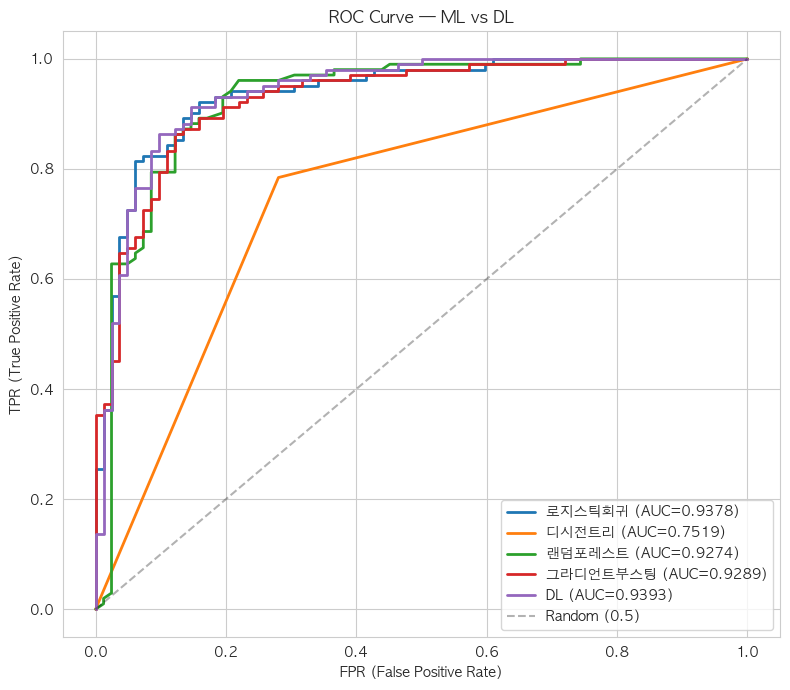

In [51]:
# ROC Curve 전체 비교
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))

for name, prob in [*ml_probs.items(), ('DL', y_prob_dl)]:
  fpr, tpr, _ = roc_curve(y_test, prob)
  auc = roc_auc_score(y_test, prob)
  plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (0.5)')
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('ROC Curve — ML vs DL')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 최종 비교 — 기본 / 튜닝 / DL 중 최고 정확도 모델

In [52]:
# 모든 모델(기본 + 튜닝 + DL) 중 각 모델 유형별 최고 Accuracy만 선택
all_models = {
  '로지스틱회귀':        result_lg['Accuracy'],
  '로지스틱회귀(튜닝)':  result_lg_tuned['Accuracy'],
  '디시전트리':          result_dtc['Accuracy'],
  '디시전트리(튜닝)':    result_dtc_tuned['Accuracy'],
  '랜덤포레스트':        result_rfc['Accuracy'],
  '랜덤포레스트(튜닝)':  result_rfc_tuned['Accuracy'],
  '그라디언트부스팅':    result_gbc['Accuracy'],
  '그라디언트부스팅(튜닝)': result_gbc_tuned['Accuracy'],
  'DL':                result_dl['Accuracy'],
}

# 모델 유형별 최고 정확도만 추출
best_models = {}
model_types = ['로지스틱회귀', '디시전트리', '랜덤포레스트', '그라디언트부스팅', 'DL']

for mt in model_types:
  candidates = {k: v for k, v in all_models.items() if k.startswith(mt)}
  best_name = max(candidates, key=candidates.get)
  best_models[best_name] = candidates[best_name]

df_best = pd.DataFrame({
  'Model': best_models.keys(),
  'Accuracy': best_models.values()
})
df_best = df_best.sort_values('Accuracy', ascending=True).reset_index(drop=True)

print('=== 모델 유형별 최고 Accuracy ===')
print(df_best.to_string(index=False))

=== 모델 유형별 최고 Accuracy ===
       Model  Accuracy
   디시전트리(튜닝)  0.804348
      랜덤포레스트  0.864130
          DL  0.869565
그라디언트부스팅(튜닝)  0.880435
  로지스틱회귀(튜닝)  0.885870


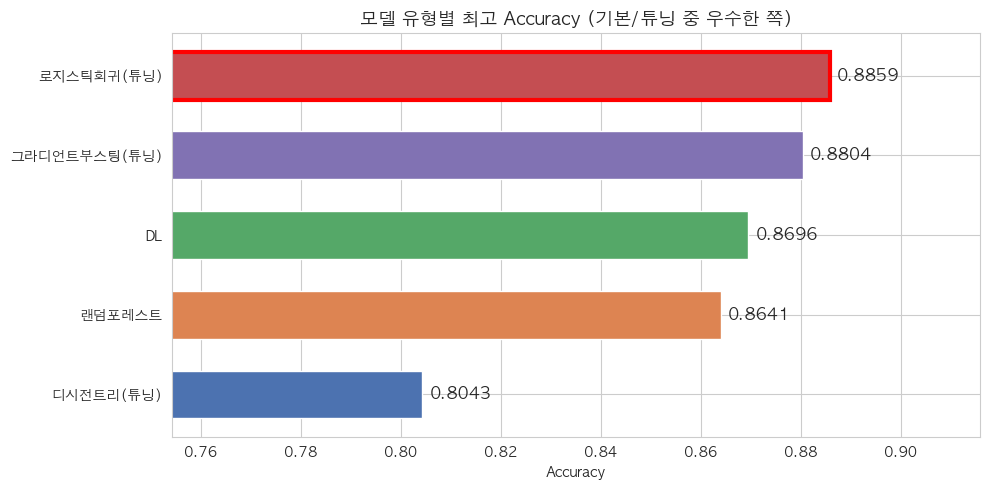


★ 최고 성능 모델: 로지스틱회귀(튜닝) (Accuracy=0.8859)


In [53]:
# 최고 정확도 모델 비교 그래프
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#4C72B0', '#DD8452', '#55A868', '#8172B3', '#C44E52']
bars = ax.barh(df_best['Model'], df_best['Accuracy'], color=colors, edgecolor='white', height=0.6)

ax.set_xlim(df_best['Accuracy'].min() - 0.05, df_best['Accuracy'].max() + 0.03)
ax.set_title('모델 유형별 최고 Accuracy (기본/튜닝 중 우수한 쪽)', fontsize=13)
ax.set_xlabel('Accuracy')

# 값 + 모델 타입(기본/튜닝) 표시
for bar in bars:
  w = bar.get_width()
  ax.annotate(f'{w:.4f}',
              (w, bar.get_y() + bar.get_height() / 2),
              ha='left', va='center', fontsize=12, fontweight='bold',
              xytext=(5, 0), textcoords='offset points')

# 최고 모델 강조
best_idx = df_best['Accuracy'].idxmax()
bars[best_idx].set_edgecolor('red')
bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.show()

winner = df_best.loc[best_idx]
print(f'\n★ 최고 성능 모델: {winner["Model"]} (Accuracy={winner["Accuracy"]:.4f})')